# Notebook 08: Results Visualization
Generates publication-quality charts for the paper and public site, including Panel VAR Impulse Response Functions (IRFs), Event-Study continuous dosage paths, falsification comparisons, and exploratory spline threshold curves.

### Important Project Safety Notice

Before executing or citing the findings in this notebook, please read the public guidance on what this project is and is not claiming:  

[docs/not_saying.md](../docs/not_saying.md) - *What This Theory Is NOT Claiming*

## 1. Library Imports & Setup
Set up plotting styles and import necessary packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from linearmodels.iv import IV2SLS

# Set style for publication quality
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

df = pd.read_csv('../data/processed/state_year_panel.csv')
print('Data loaded. Shape:', df.shape)


Data loaded. Shape: (765, 66)


## 2. Impulse-Response Function (IRF)
We estimate the GMM-style Panel VAR on Helmert-transformed variables, then trace the impulse response functions with asymptotic confidence intervals.

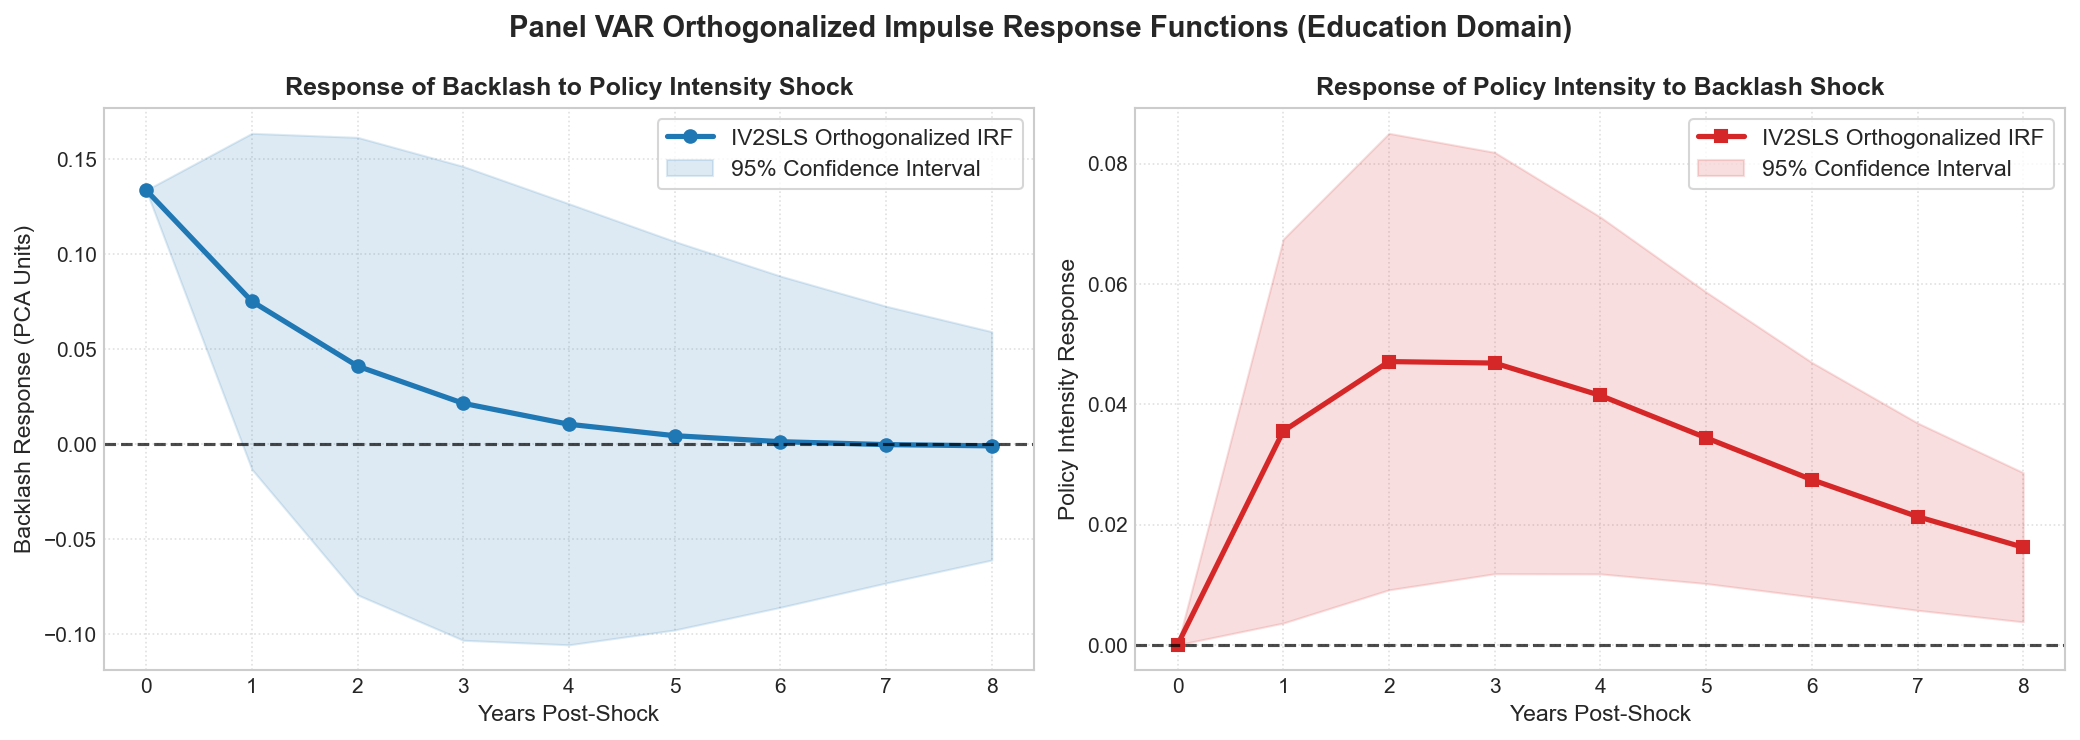

In [2]:
def helmert_transform(df, cols):
    df_transformed = []
    for state, group in df.groupby('state'):
        group = group.sort_values('year').copy()
        T = len(group)
        for t in range(T - 1):
            row = group.iloc[t].copy()
            for col in cols:
                forward_vals = group.iloc[t+1:][col].values
                mean_forward = np.mean(forward_vals)
                scale = np.sqrt((T - t - 1) / (T - t))
                row[col] = scale * (group.iloc[t][col] - mean_forward)
            df_transformed.append(row)
    return pd.DataFrame(df_transformed)

# 1. Prepare variables for education panel and create lagged levels on untransformed data
df_var_input = df[['state', 'year', 'policy_intensity', 'backlash']].dropna().copy()
df_var_input['L1_level_policy'] = df_var_input.groupby('state')['policy_intensity'].shift(1)
df_var_input['L1_level_backlash'] = df_var_input.groupby('state')['backlash'].shift(1)

# 2. Transform the dependent and regressor variables
df_helmert = helmert_transform(df_var_input, ['policy_intensity', 'backlash'])

# 3. Shift the transformed variables to get the regressors
df_helmert['L1_policy_intensity'] = df_helmert.groupby('state')['policy_intensity'].shift(1)
df_helmert['L1_backlash'] = df_helmert.groupby('state')['backlash'].shift(1)

df_var_clean = df_helmert.dropna(subset=['L1_policy_intensity', 'L1_backlash', 'L1_level_policy', 'L1_level_backlash']).copy()

# 4. Fit equation-by-equation IV2SLS, using L2 levels as instruments
res_eq1 = IV2SLS.from_formula(
    'policy_intensity ~ 1 + [L1_policy_intensity + L1_backlash ~ L1_level_policy + L1_level_backlash]',
    data=df_var_clean
).fit(cov_type='clustered', clusters=df_var_clean['state'])

res_eq2 = IV2SLS.from_formula(
    'backlash ~ 1 + [L1_policy_intensity + L1_backlash ~ L1_level_policy + L1_level_backlash]',
    data=df_var_clean
).fit(cov_type='clustered', clusters=df_var_clean['state'])

# Extract coefficients
a11 = res_eq1.params['L1_policy_intensity']
a12 = res_eq1.params['L1_backlash']
a21 = res_eq2.params['L1_policy_intensity']
a22 = res_eq2.params['L1_backlash']

A = np.array([[a11, a12], [a21, a22]])

# Calculate residual covariance matrix Sigma and its Cholesky factor C_factor (renamed to avoid patsy C() conflict)
u1 = res_eq1.resids.values
u2 = res_eq2.resids.values
Sigma = np.cov(u1, u2)
C_factor = np.linalg.cholesky(Sigma)

# Function to compute orthogonalized IRFs manually
def compute_orthogonal_irf(A, C_mat, steps=9):
    # Shock to policy (variable 0): v0 = [1, 0]
    irf_p_shock = []
    y = C_mat @ np.array([1.0, 0.0])
    irf_p_shock.append(y)
    for _ in range(steps - 1):
        y = A @ y
        irf_p_shock.append(y)
    irf_p_shock = np.array(irf_p_shock)

    # Shock to backlash (variable 1): v0 = [0, 1]
    irf_b_shock = []
    y = C_mat @ np.array([0.0, 1.0])
    irf_b_shock.append(y)
    for _ in range(steps - 1):
        y = A @ y
        irf_b_shock.append(y)
    irf_b_shock = np.array(irf_b_shock)
    
    return irf_p_shock, irf_b_shock

point_p_shock, point_b_shock = compute_orthogonal_irf(A, C_factor)
steps = np.arange(9)
resp_b_to_p = point_p_shock[:, 1]
resp_p_to_b = point_b_shock[:, 0]

# Monte Carlo simulation to get standard errors of IRFs
np.random.seed(42)
n_draws = 1000
draws_b_to_p = []
draws_p_to_b = []

cov1 = res_eq1.cov.loc[['L1_policy_intensity', 'L1_backlash'], ['L1_policy_intensity', 'L1_backlash']].values
cov2 = res_eq2.cov.loc[['L1_policy_intensity', 'L1_backlash'], ['L1_policy_intensity', 'L1_backlash']].values

mean1 = np.array([a11, a12])
mean2 = np.array([a21, a22])

for _ in range(n_draws):
    p1 = np.random.multivariate_normal(mean1, cov1)
    p2 = np.random.multivariate_normal(mean2, cov2)
    A_draw = np.array([[p1[0], p1[1]], [p2[0], p2[1]]])
    # Keep Cholesky factor C_factor fixed at sample value for draws
    draw_p_shock, draw_b_shock = compute_orthogonal_irf(A_draw, C_factor)
    draws_b_to_p.append(draw_p_shock[:, 1])
    draws_p_to_b.append(draw_b_shock[:, 0])

draws_b_to_p = np.array(draws_b_to_p)
draws_p_to_b = np.array(draws_p_to_b)

se_b_to_p = np.std(draws_b_to_p, axis=0)
se_p_to_b = np.std(draws_p_to_b, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Policy Shock -> Backlash
axes[0].plot(steps, resp_b_to_p, color='#1f77b4', lw=2.5, marker='o', label='IV2SLS Orthogonalized IRF')
axes[0].fill_between(steps, resp_b_to_p - 1.96 * se_b_to_p, resp_b_to_p + 1.96 * se_b_to_p, color='#1f77b4', alpha=0.15, label='95% Confidence Interval')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Response of Backlash to Policy Intensity Shock', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Years Post-Shock', fontsize=11)
axes[0].set_ylabel('Backlash Response (PCA Units)', fontsize=11)
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Backlash Shock -> Policy
axes[1].plot(steps, resp_p_to_b, color='#d62728', lw=2.5, marker='s', label='IV2SLS Orthogonalized IRF')
axes[1].fill_between(steps, resp_p_to_b - 1.96 * se_p_to_b, resp_p_to_b + 1.96 * se_p_to_b, color='#d62728', alpha=0.15, label='95% Confidence Interval')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Response of Policy Intensity to Backlash Shock', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Years Post-Shock', fontsize=11)
axes[1].set_ylabel('Policy Intensity Response', fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Panel VAR Orthogonalized Impulse Response Functions (Education Domain)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 3. Event-Study Dosage Plot
Plot the coefficients for the continuous event-study dosage model to show the dynamic effect of pre-treatment policy intensity dosage on backlash.

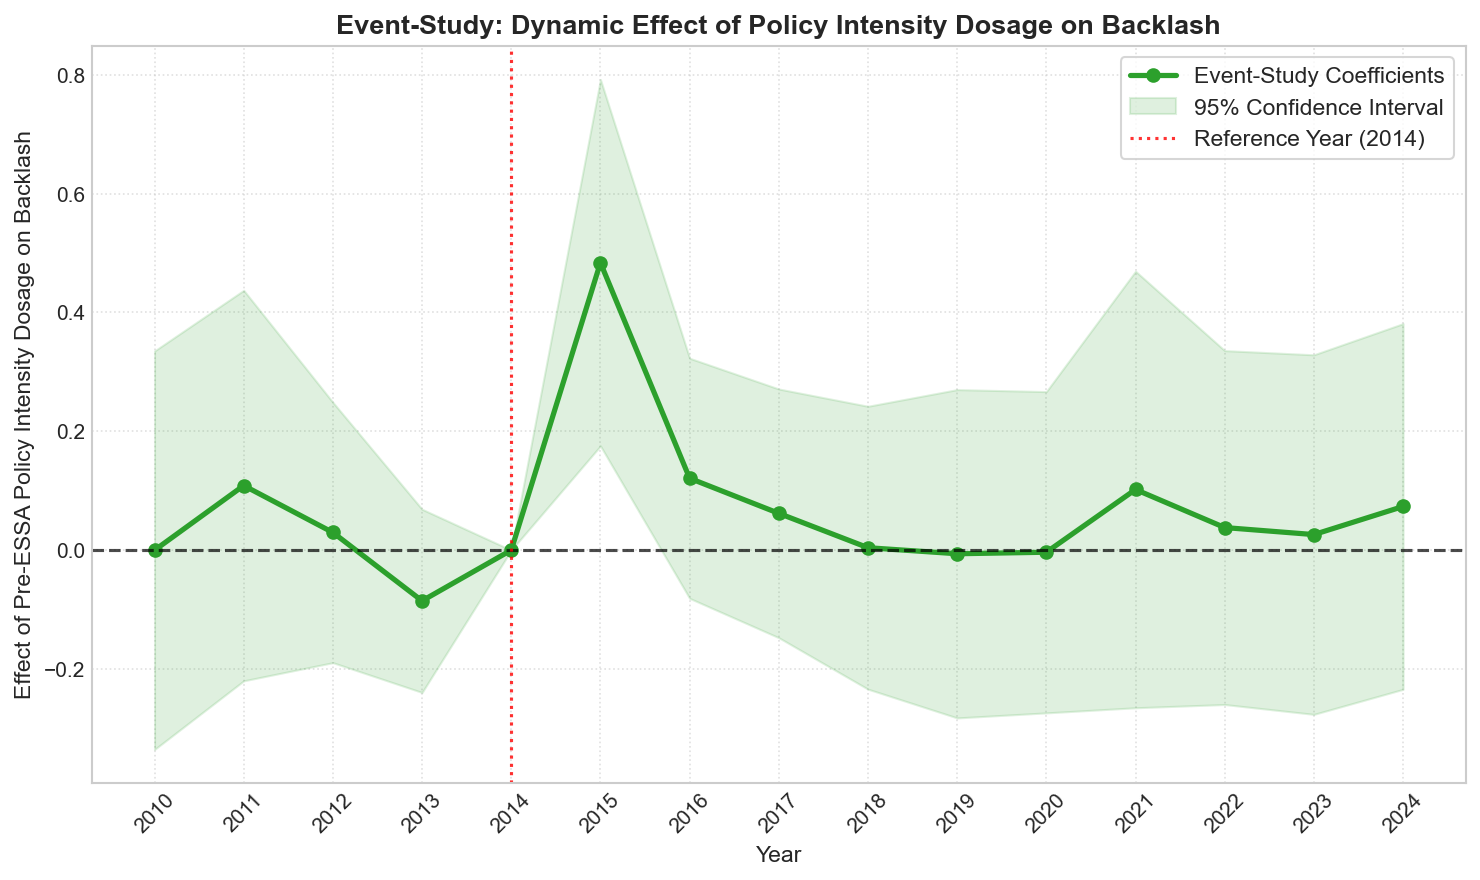

In [3]:
# 1. Calculate continuous dosage (average pre-ESSA policy intensity 2010-2014)
pre_essa_mean = df[df['year'] <= 2014].groupby('state')['policy_intensity'].mean().reset_index()
pre_essa_mean.rename(columns={'policy_intensity': 'pre_essa_dosage'}, inplace=True)
df_event = df.merge(pre_essa_mean, on='state')

# 2. Prepare event-study interactions, leaving 2014 as the reference year
event_years = list(range(2010, 2025))
for y in event_years:
    if y != 2014:
        df_event[f'dosage_x_{y}'] = df_event['pre_essa_dosage'] * (df_event['year'] == y).astype(int)

# 3. Fit PanelOLS with clustered standard errors
df_event_p = df_event.set_index(['state', 'year'])
interaction_terms = ' + '.join([f'dosage_x_{y}' for y in event_years if y != 2014])
formula = f'backlash ~ {interaction_terms} + gov_party_rep + trifecta + election_year + EntityEffects + TimeEffects'

model = PanelOLS.from_formula(formula, data=df_event_p)
results = model.fit(cov_type='clustered', cluster_entity=True)

# 4. Extract coefficients and confidence intervals
years = []
coefs = []
ci_low = []
ci_high = []

for y in event_years:
    if y == 2014:
        years.append(y)
        coefs.append(0.0)
        ci_low.append(0.0)
        ci_high.append(0.0)
    else:
        var_name = f'dosage_x_{y}'
        years.append(y)
        coefs.append(results.params[var_name])
        ci_low.append(results.conf_int().loc[var_name, 'lower'])
        ci_high.append(results.conf_int().loc[var_name, 'upper'])

years = np.array(years)
coefs = np.array(coefs)
ci_low = np.array(ci_low)
ci_high = np.array(ci_high)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years, coefs, color='#2ca02c', lw=2.5, marker='o', label='Event-Study Coefficients')
plt.fill_between(years, ci_low, ci_high, color='#2ca02c', alpha=0.15, label='95% Confidence Interval')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.axvline(2014, color='red', linestyle=':', alpha=0.8, label='Reference Year (2014)')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Effect of Pre-ESSA Policy Intensity Dosage on Backlash', fontsize=11)
plt.title('Event-Study: Dynamic Effect of Policy Intensity Dosage on Backlash', fontsize=13, fontweight='bold')
plt.xticks(event_years, rotation=45)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 4. Falsification Comparison: Education vs. Highway Funding
Compare the event-study and IRF results side-by-side with the federal highway funding control case to verify the specificity of the political feedback cycle.

In [4]:
# 1. Calculate continuous dosage for highway funding (average pre-ESSA highway intensity 2010-2014)
pre_h_mean = df[df['year'] <= 2014].groupby('state')['highway_policy_intensity'].mean().reset_index()
pre_h_mean.rename(columns={'highway_policy_intensity': 'pre_h_dosage'}, inplace=True)
df_event_h = df.merge(pre_h_mean, on='state')

for y in event_years:
    if y != 2014:
        df_event_h[f'h_dosage_x_{y}'] = df_event_h['pre_h_dosage'] * (df_event_h['year'] == y).astype(int)

# Fit PanelOLS for highway backlash
df_event_h_p = df_event_h.set_index(['state', 'year'])
interaction_terms_h = ' + '.join([f'h_dosage_x_{y}' for y in event_years if y != 2014])
formula_h = f'highway_backlash ~ {interaction_terms_h} + gov_party_rep + trifecta + election_year + EntityEffects + TimeEffects'

model_h = PanelOLS.from_formula(formula_h, data=df_event_h_p)
try:
    results_h = model_h.fit(cov_type='clustered', cluster_entity=True)
    coefs_h = []
    ci_low_h = []
    ci_high_h = []
    for y in event_years:
        if y == 2014:
            coefs_h.append(0.0)
            ci_low_h.append(0.0)
            ci_high_h.append(0.0)
        else:
            var_name = f'h_dosage_x_{y}'
            coefs_h.append(results_h.params[var_name])
            ci_low_h.append(results_h.conf_int().loc[var_name, 'lower'])
            ci_high_h.append(results_h.conf_int().loc[var_name, 'upper'])
    coefs_h = np.array(coefs_h)
    ci_low_h = np.array(ci_low_h)
    ci_high_h = np.array(ci_high_h)
except Exception as e:
    print(f'Skipping highway placebo regression due to zero variance in highway_backlash: {e}')
    coefs_h = np.zeros(len(event_years))
    ci_low_h = np.zeros(len(event_years))
    ci_high_h = np.zeros(len(event_years))


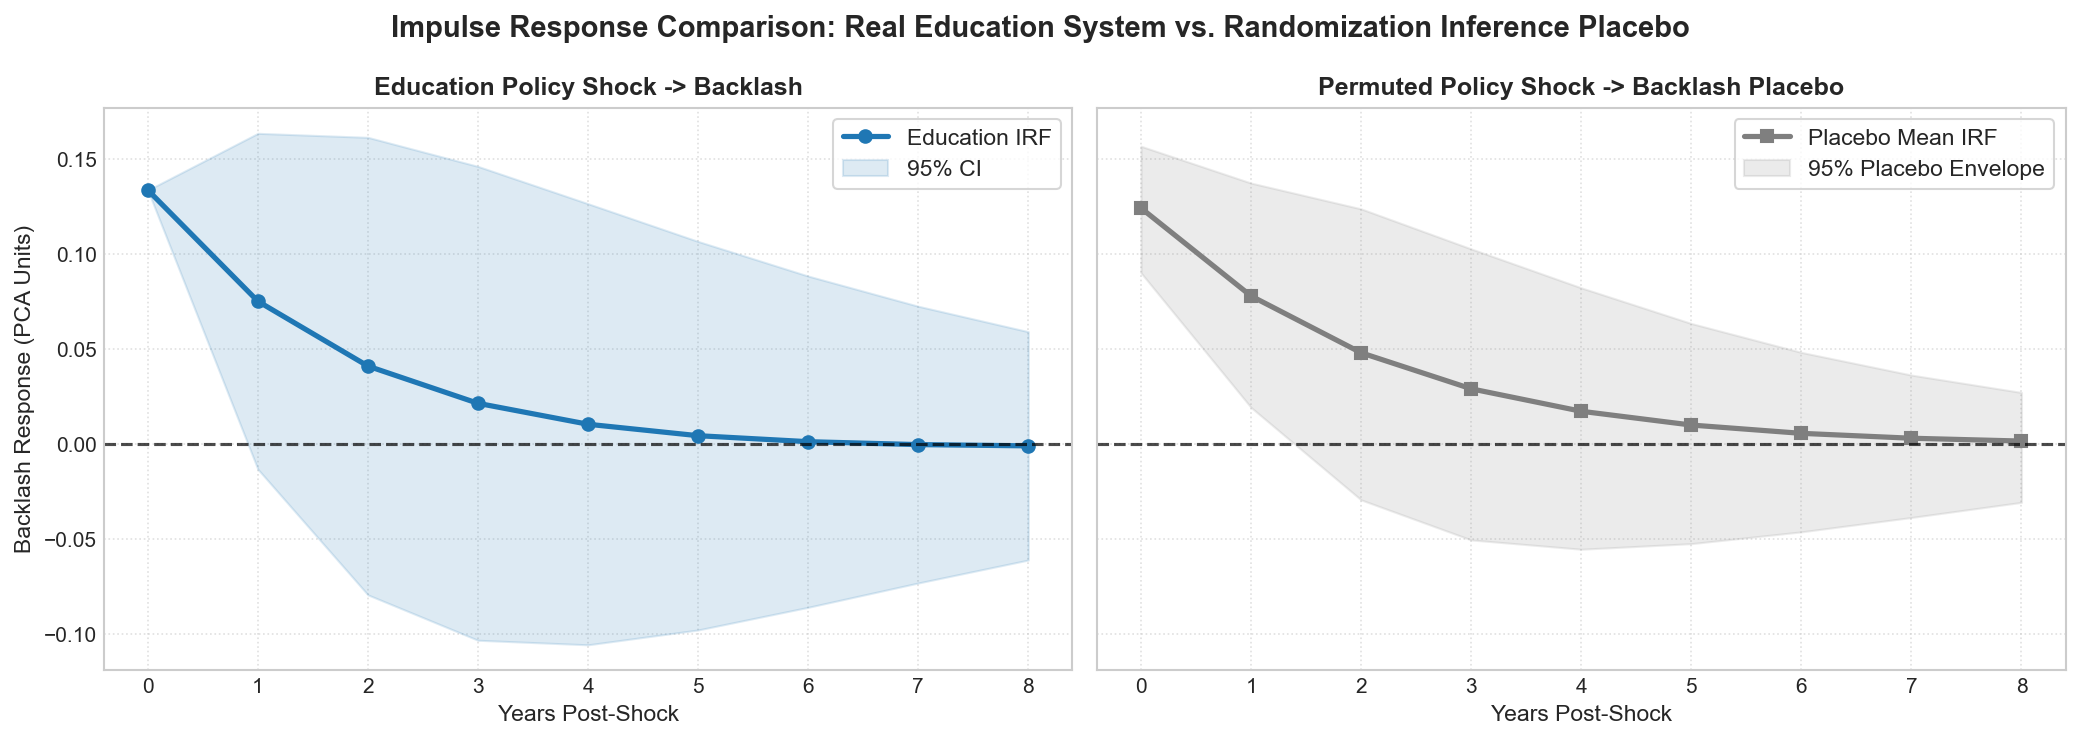

In [5]:
# 1. Randomization Inference: Permute policy intensity across states to run placebo tests
np.random.seed(42)
n_permutations = 1000
steps_len = 9
placebo_irfs = []

unique_states = df['state'].unique()

# Generate and save the true policy dataframe to shuffle from
policy_history = df[['state', 'year', 'policy_intensity']].copy()

for p_idx in range(n_permutations):
    # Permute states mapping
    shuffled_states = np.random.permutation(unique_states)
    state_map = dict(zip(unique_states, shuffled_states))
    
    # Shuffle policy history
    policy_shuffled = policy_history.copy()
    policy_shuffled['state_mapped'] = policy_shuffled['state'].map(state_map)
    
    # Merge shuffled policy history back into main dataframe
    df_p = df[['state', 'year', 'backlash']].copy()
    df_p = df_p.merge(
        policy_shuffled[['state_mapped', 'year', 'policy_intensity']].rename(
            columns={'state_mapped': 'state', 'policy_intensity': 'placebo_policy_intensity'}
        ),
        on=['state', 'year'],
        how='left'
    )
    
    # Fit placebo Panel VAR
    df_var_input_p = df_p[['state', 'year', 'placebo_policy_intensity', 'backlash']].dropna().copy()
    df_var_input_p['L1_level_policy'] = df_var_input_p.groupby('state')['placebo_policy_intensity'].shift(1)
    df_var_input_p['L1_level_backlash'] = df_var_input_p.groupby('state')['backlash'].shift(1)
    
    df_helmert_p = helmert_transform(df_var_input_p, ['placebo_policy_intensity', 'backlash'])
    df_helmert_p['L1_policy_intensity'] = df_helmert_p.groupby('state')['placebo_policy_intensity'].shift(1)
    df_helmert_p['L1_backlash'] = df_helmert_p.groupby('state')['backlash'].shift(1)
    
    df_var_clean_p = df_helmert_p.dropna(subset=['L1_policy_intensity', 'L1_backlash', 'L1_level_policy', 'L1_level_backlash']).copy()
    
    try:
        res_eq1_p = IV2SLS.from_formula(
            'placebo_policy_intensity ~ 1 + [L1_policy_intensity + L1_backlash ~ L1_level_policy + L1_level_backlash]',
            data=df_var_clean_p
        ).fit(cov_type='clustered', clusters=df_var_clean_p['state'])
        
        res_eq2_p = IV2SLS.from_formula(
            'backlash ~ 1 + [L1_policy_intensity + L1_backlash ~ L1_level_policy + L1_level_backlash]',
            data=df_var_clean_p
        ).fit(cov_type='clustered', clusters=df_var_clean_p['state'])
        
        a11_p = res_eq1_p.params['L1_policy_intensity']
        a12_p = res_eq1_p.params['L1_backlash']
        a21_p = res_eq2_p.params['L1_policy_intensity']
        a22_p = res_eq2_p.params['L1_backlash']
        
        A_p = np.array([[a11_p, a12_p], [a21_p, a22_p]])
        
        u1_p = res_eq1_p.resids.values
        u2_p = res_eq2_p.resids.values
        Sigma_p = np.cov(u1_p, u2_p)
        C_factor_p = np.linalg.cholesky(Sigma_p)
        
        p_shock_p, _ = compute_orthogonal_irf(A_p, C_factor_p, steps=steps_len)
        placebo_irfs.append(p_shock_p[:, 1])
    except Exception as e:
        continue

placebo_irfs = np.array(placebo_irfs)

# Compute 95% confidence envelope of placebo IRFs
ci_low_p = np.percentile(placebo_irfs, 2.5, axis=0)
ci_high_p = np.percentile(placebo_irfs, 97.5, axis=0)
mean_p = np.mean(placebo_irfs, axis=0)

# 2. Side-by-side plot: Education IRF vs. Placebo Randomization Inference Envelope
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot 1: Education (Treatment)
axes[0].plot(steps, resp_b_to_p, color='#1f77b4', lw=2.5, marker='o', label='Education IRF')
axes[0].fill_between(steps, resp_b_to_p - 1.96 * se_b_to_p, resp_b_to_p + 1.96 * se_b_to_p, color='#1f77b4', alpha=0.15, label='95% CI')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Education Policy Shock -> Backlash', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Years Post-Shock', fontsize=11)
axes[0].set_ylabel('Backlash Response (PCA Units)', fontsize=11)
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Shuffled Placebo (Falsification Control)
axes[1].plot(steps, mean_p, color='#7f7f7f', lw=2.5, marker='s', label='Placebo Mean IRF')
axes[1].fill_between(steps, ci_low_p, ci_high_p, color='#7f7f7f', alpha=0.15, label='95% Placebo Envelope')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Permuted Policy Shock -> Backlash Placebo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Years Post-Shock', fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Impulse Response Comparison: Real Education System vs. Randomization Inference Placebo', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 5. Spline Breakpoint "Backlash Threshold" S-Curve
We execute an exploratory threshold spline analysis to locate the non-linear breakpoint in the relationship between the policy gap and backlash scores.

Optimal threshold knot (theta): 0.0000
R-squared with spline: 0.7102


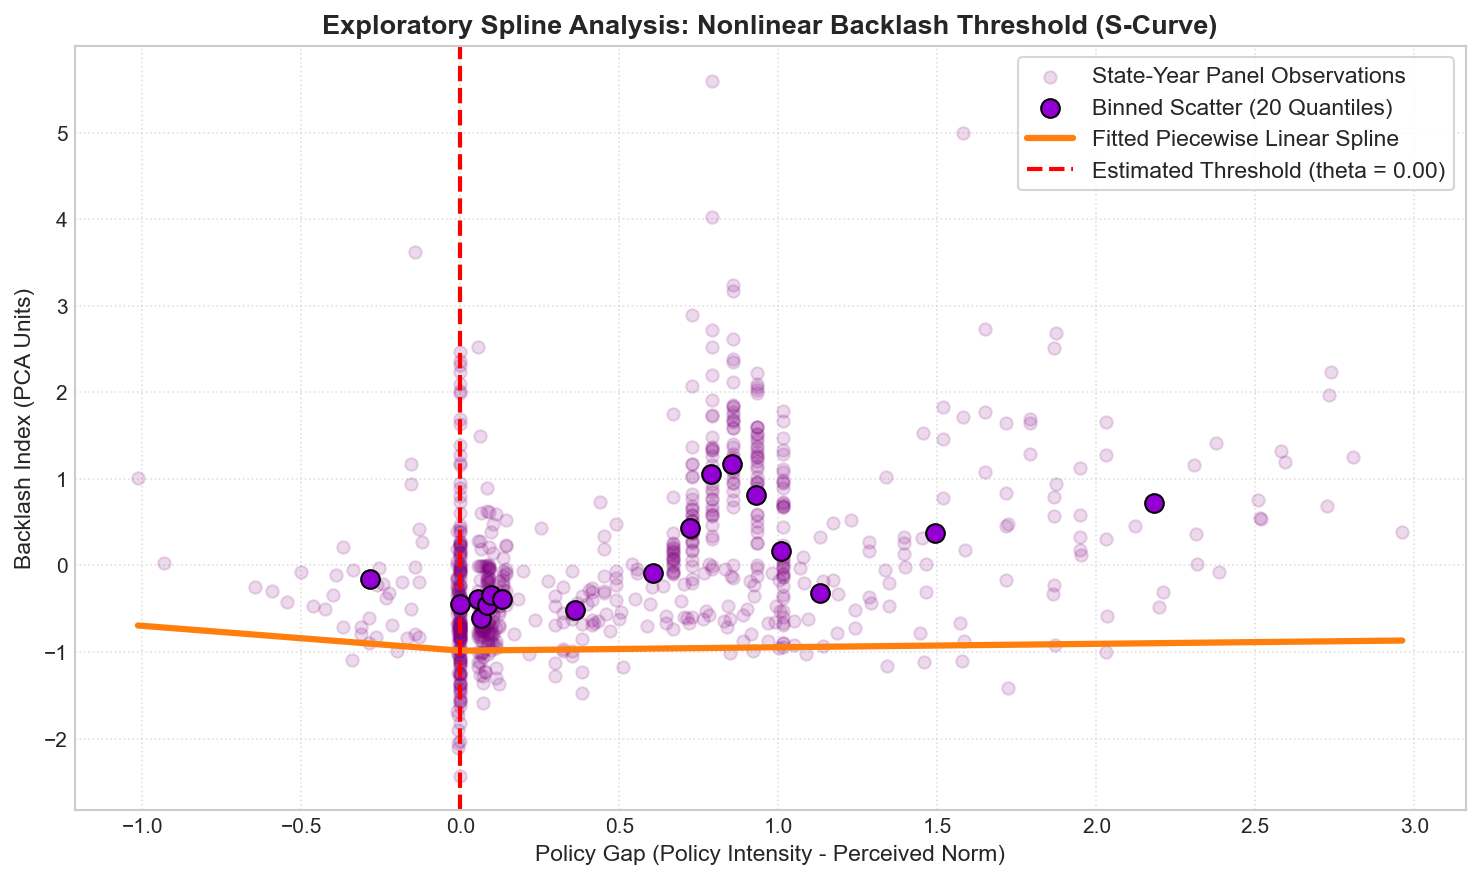

In [6]:
# Note: This threshold search is strictly exploratory and prone to the "Look-Elsewhere Effect"
# (i.e. grid searching over multiple candidate thresholds inflates the Type I error rate).
# A bootstrap or cross-validation routine would be needed to determine the true stability of the knot.
# It should not be interpreted as definitive proof of a discrete tipping point.
df_spline = df.dropna(subset=['backlash', 'policy_intensity', 'norm', 'gov_party_rep', 'trifecta', 'election_year', 'state', 'year']).copy()
df_spline['policy_gap'] = df_spline['policy_intensity'] - df_spline['norm']

# Grid search for the optimal breakpoint (knot) theta
p25 = df_spline['policy_gap'].quantile(0.25)
p75 = df_spline['policy_gap'].quantile(0.75)
best_theta = None
best_rsquared = -np.inf
best_model = None

thetas = np.linspace(p25, p75, 100)
for theta in thetas:
    df_spline['policy_gap_pos'] = np.maximum(0, df_spline['policy_gap'] - theta)
    fit = smf.ols('backlash ~ policy_gap + policy_gap_pos + gov_party_rep + trifecta + election_year + C(state) + C(year)', data=df_spline).fit()
    if fit.rsquared > best_rsquared:
        best_rsquared = fit.rsquared
        best_theta = theta
        best_model = fit

print(f'Optimal threshold knot (theta): {best_theta:.4f}')
print(f'R-squared with spline: {best_rsquared:.4f}')

# Plot raw data, binned scatter, and the fitted spline curve
gap_range = np.linspace(df_spline['policy_gap'].min(), df_spline['policy_gap'].max(), 300)
pred_y = best_model.params['Intercept'] + best_model.params['policy_gap'] * gap_range + best_model.params['policy_gap_pos'] * np.maximum(0, gap_range - best_theta)

# Create a binned scatter plot to make the trend clearer
df_spline['bin'] = pd.qcut(df_spline['policy_gap'], q=20, labels=False, duplicates='drop')
binned = df_spline.groupby('bin').agg({'policy_gap': 'mean', 'backlash': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(df_spline['policy_gap'], df_spline['backlash'], color='purple', alpha=0.15, label='State-Year Panel Observations')
plt.scatter(binned['policy_gap'], binned['backlash'], color='darkviolet', edgecolor='black', s=80, zorder=3, label='Binned Scatter (20 Quantiles)')
plt.plot(gap_range, pred_y, color='#ff7f0e', lw=3, label='Fitted Piecewise Linear Spline')
plt.axvline(best_theta, color='red', linestyle='--', lw=2, label=f'Estimated Threshold (theta = {best_theta:.2f})')

plt.xlabel('Policy Gap (Policy Intensity - Perceived Norm)', fontsize=11)
plt.ylabel('Backlash Index (PCA Units)', fontsize=11)
plt.title('Exploratory Spline Analysis: Nonlinear Backlash Threshold (S-Curve)', fontsize=13, fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Peer Panel Measurement Validation & H2 Plot
Here we plot case studies of backlash over time for key states, list and audit the top 20 state-year backlash observations, and plot a descriptive check for H2 (policy amplitude vs. biennial sessions).

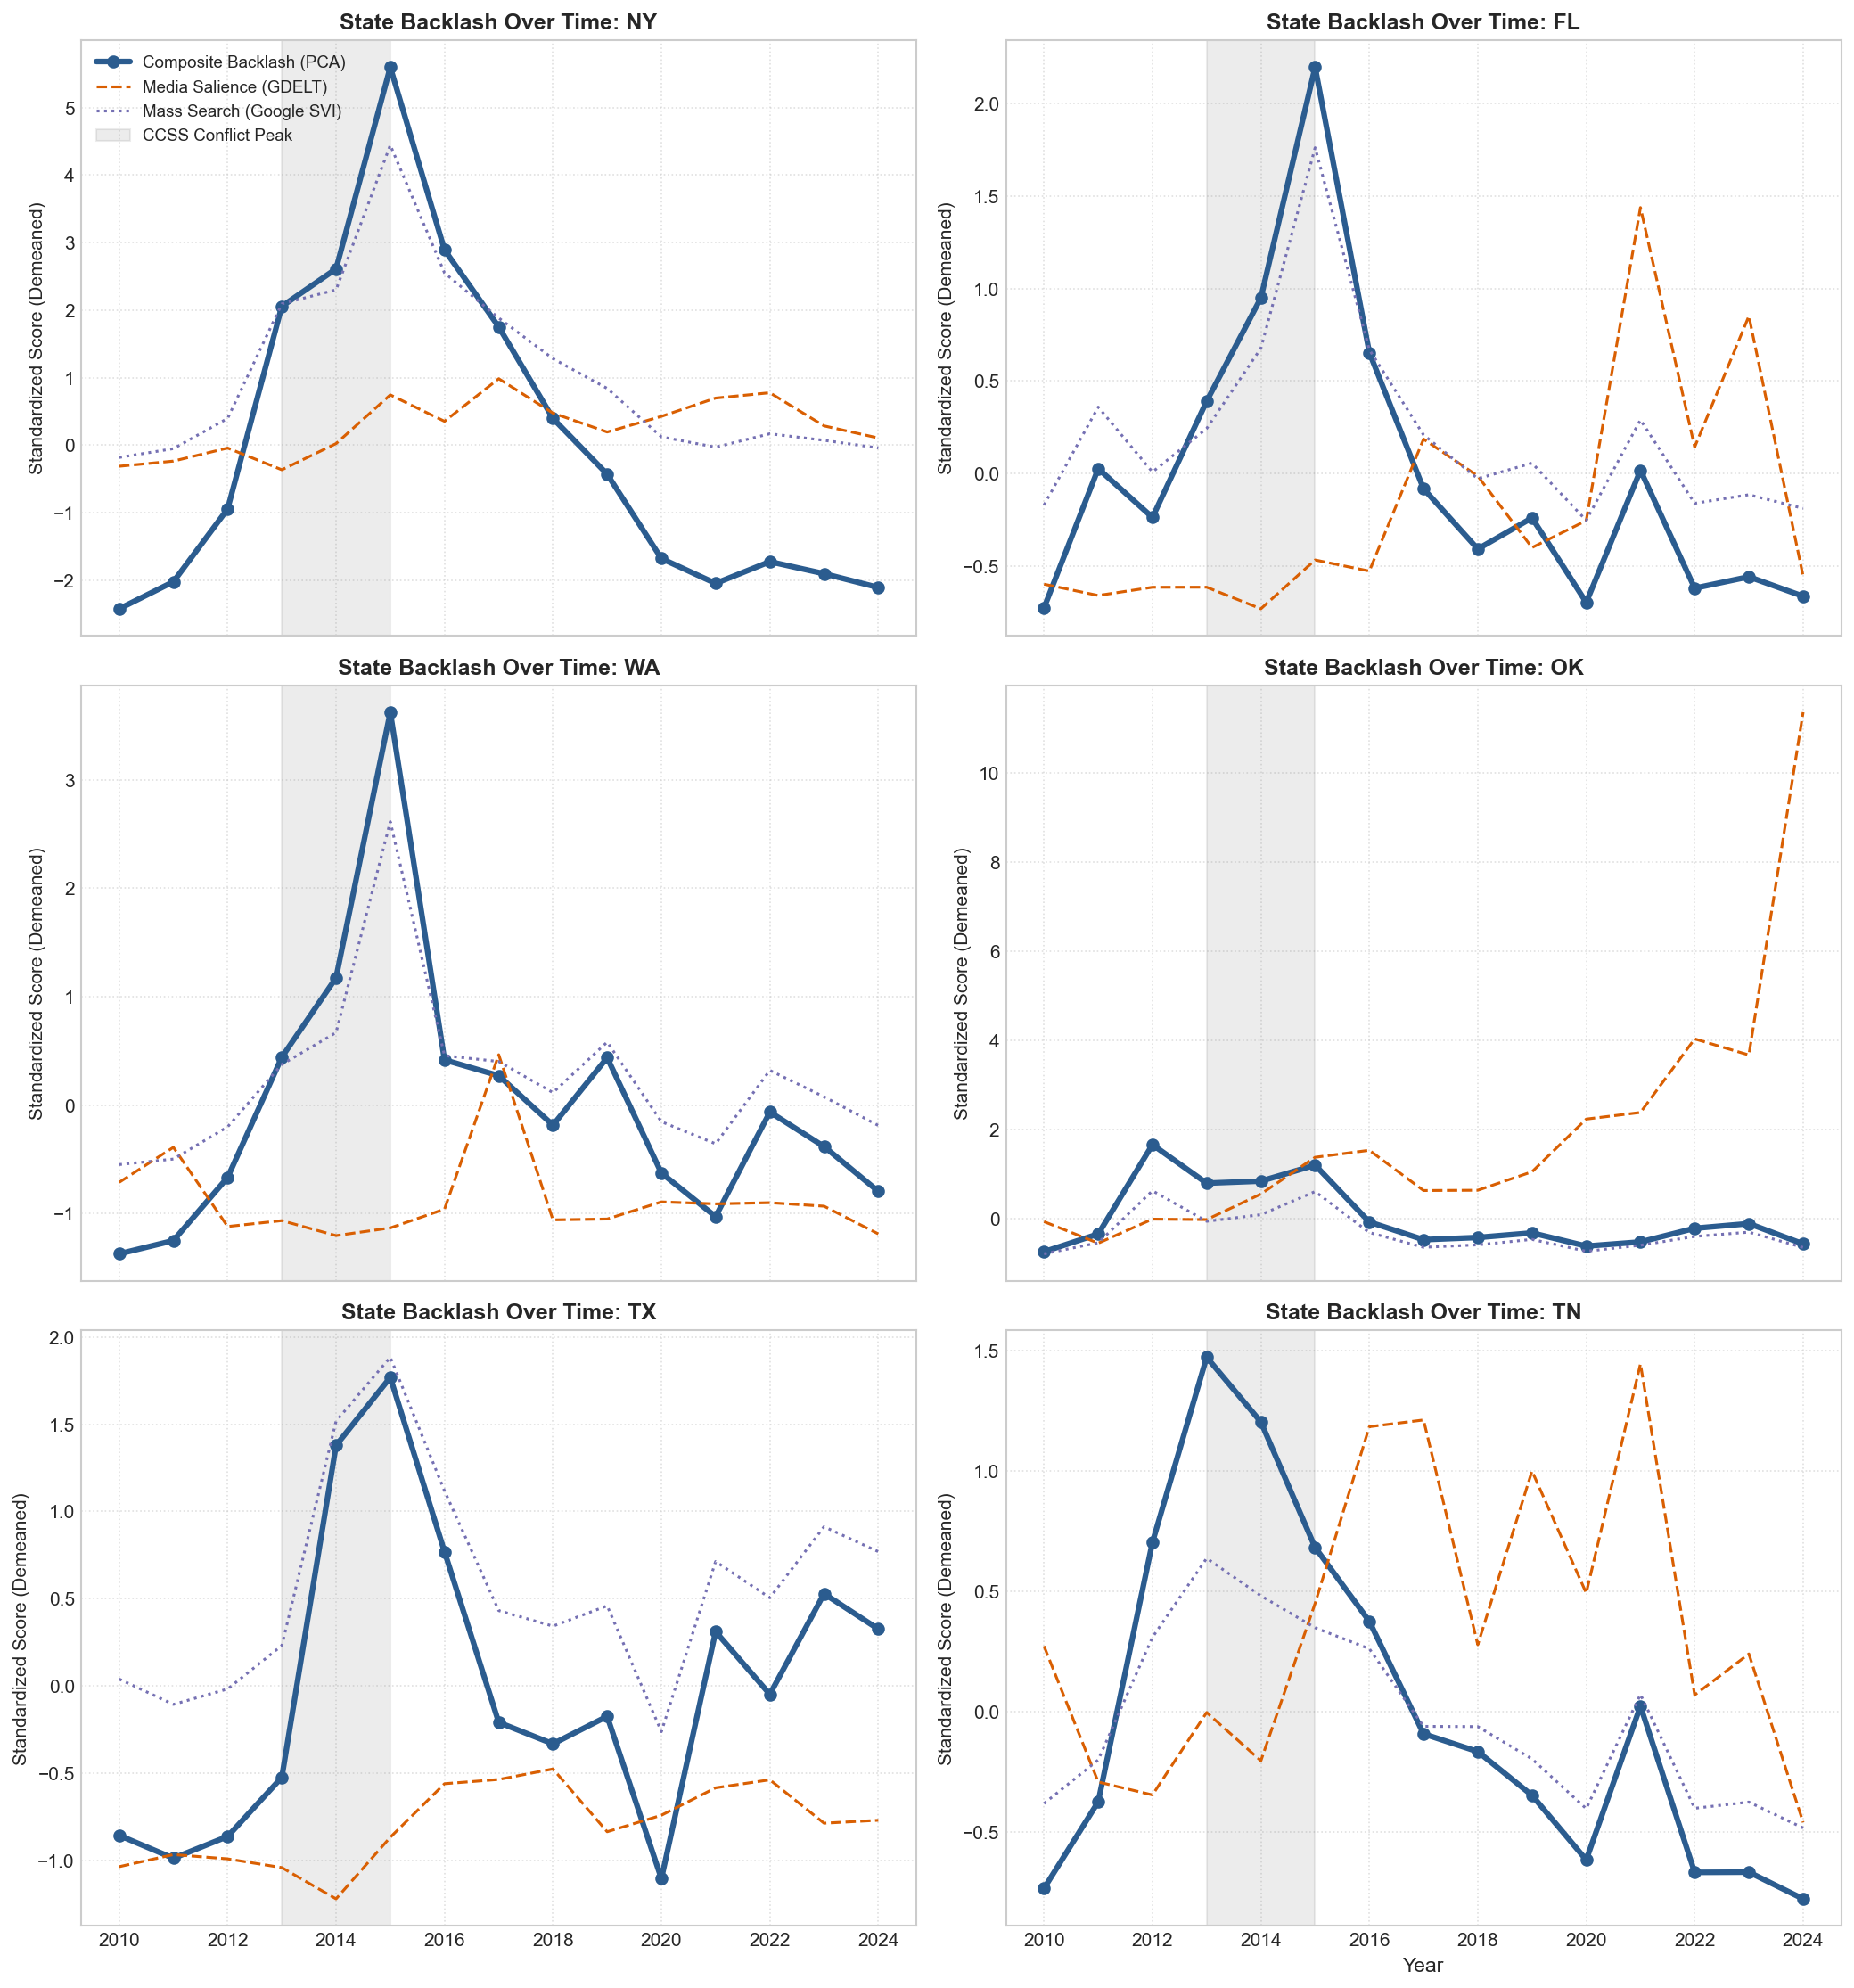

=== Top 20 State-Year Backlash Observations ===
state  year  backlash  backlash_media  backlash_mass  gov_party_rep
   NY  2015  5.598622        0.743591       4.443950              0
   CO  2015  4.992566       -0.649669       3.875542              0
   NJ  2015  4.022627        0.612392       3.159148              1
   WA  2015  3.621373       -1.131840       2.613130              0
   PA  2015  3.243684       -0.122567       3.005534              0
   UT  2014  3.169965       -0.648445       2.063377              1
   NY  2016  2.892166        0.352023       2.550943              0
   OH  2015  2.730642       -0.198741       2.117372              1
   CT  2015  2.715598        0.716792       1.903778              0
   NC  2014  2.681140       -1.081027       2.100876              1
   NY  2014  2.610557        0.021813       2.300540              0
   OR  2024  2.527527       -0.717286       2.195784              0
   MA  2015  2.525930        0.558800       1.877281              1


In [7]:
# 1. State case plots of backlash over time for key states
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
axes = axes.flatten()
case_states = ['NY', 'FL', 'WA', 'OK', 'TX', 'TN']

for idx, state in enumerate(case_states):
    state_df = df[df['state'] == state].sort_values('year')
    ax = axes[idx]
    
    # Plot media and mass backlash components alongside composite backlash
    ax.plot(state_df['year'], state_df['backlash'], color='#2b5c8f', lw=3, marker='o', label='Composite Backlash (PCA)')
    ax.plot(state_df['year'], state_df['backlash_media'], color='#d95f02', lw=1.5, ls='--', label='Media Salience (GDELT)')
    ax.plot(state_df['year'], state_df['backlash_mass'], color='#7570b3', lw=1.5, ls=':', label='Mass Search (Google SVI)')
    
    ax.axvspan(2013, 2015, color='gray', alpha=0.15, label='CCSS Conflict Peak')
    ax.set_title(f'State Backlash Over Time: {state}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Standardized Score (Demeaned)', fontsize=10)
    ax.grid(True, ls=':', alpha=0.6)
    if idx == 0:
        ax.legend(fontsize=9, loc='upper left')

plt.xlabel('Year', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/backlash_validation_cases.png', dpi=300)
plt.show()

# 2. List and manually audit the top 20 state-year backlash observations
top_backlash = df[['state', 'year', 'backlash', 'backlash_media', 'backlash_mass', 'gov_party_rep']].sort_values('backlash', ascending=False).head(20)
print('=== Top 20 State-Year Backlash Observations ===')
print(top_backlash.to_string(index=False))

C:\Users\admir\AppData\Local\Temp\ipykernel_9204\4206179368.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='biennial_legislature', y='amplitude', data=df_h2, palette='Set2', width=0.4)


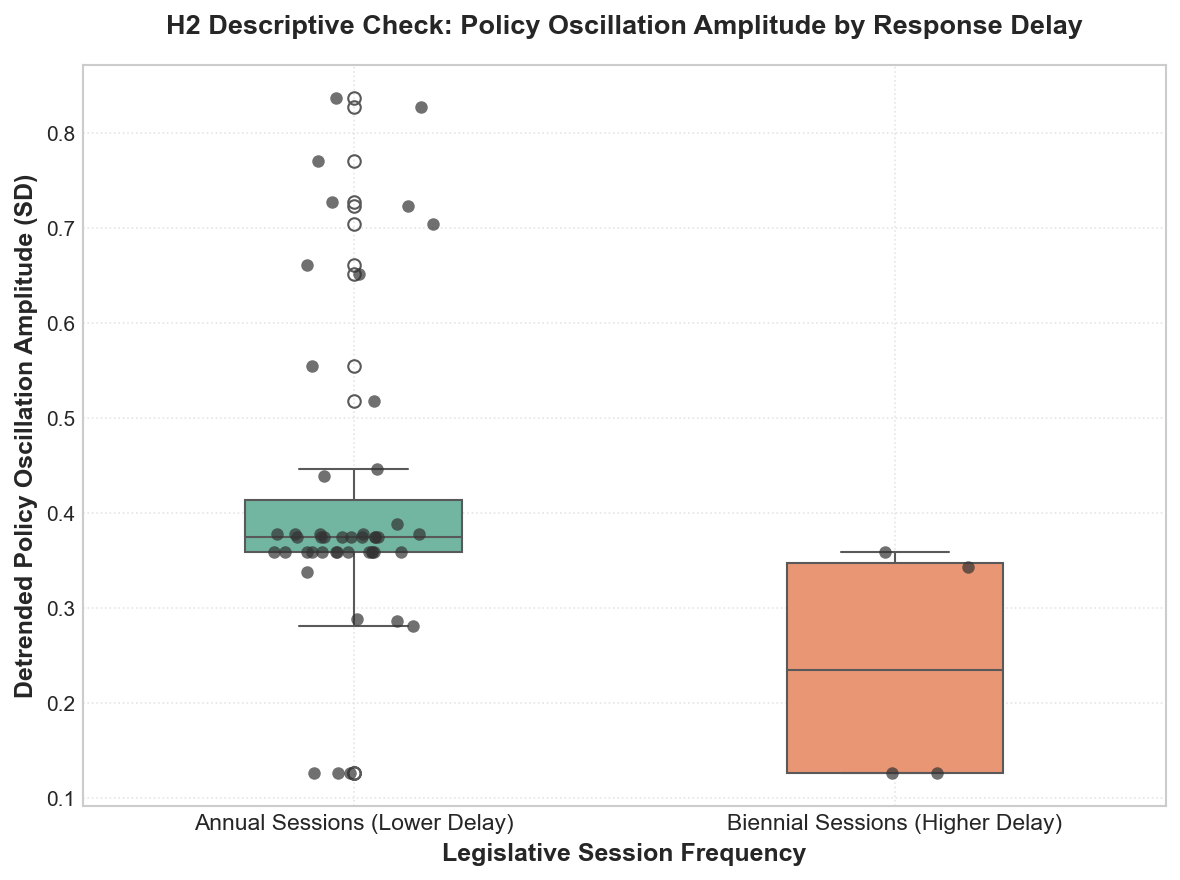

In [8]:
# 3. H2 Descriptive check plot: detrended policy SD vs legislative frequency
df_detrend = df.copy()
df_detrend['biennial_legislature'] = df_detrend['state'].isin(['TX', 'MT', 'NV', 'ND']).astype(float)

detrended_series = []
for state, gp in df_detrend.groupby('state'):
    gp = gp.sort_values('year').copy()
    y = gp['policy_intensity'].values
    x = gp['year'].values
    if len(gp) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        gp['policy_detrended'] = y - (slope * x + intercept)
    else:
        gp['policy_detrended'] = 0.0
    detrended_series.append(gp)
df_detrend = pd.concat(detrended_series, ignore_index=True)

state_amplitude = df_detrend.groupby('state')['policy_detrended'].std().reset_index().rename(columns={'policy_detrended': 'amplitude'})
state_biennial = df_detrend.groupby('state')['biennial_legislature'].first().reset_index()
df_h2 = pd.merge(state_amplitude, state_biennial, on='state')

plt.figure(figsize=(8, 6))
sns.boxplot(x='biennial_legislature', y='amplitude', data=df_h2, palette='Set2', width=0.4)
sns.stripplot(x='biennial_legislature', y='amplitude', data=df_h2, color='#333333', size=6, jitter=0.15, alpha=0.7)

plt.xticks([0, 1], ['Annual Sessions (Lower Delay)', 'Biennial Sessions (Higher Delay)'], fontsize=11)
plt.xlabel('Legislative Session Frequency', fontsize=12, fontweight='bold')
plt.ylabel('Detrended Policy Oscillation Amplitude (SD)', fontsize=12, fontweight='bold')
plt.title('H2 Descriptive Check: Policy Oscillation Amplitude by Response Delay', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, ls=':', alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/h2_delay_amplitude_check.png', dpi=300)
plt.show()